# Laser illumination

In [1]:
import os
import sys
import argparse
import string
import math

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from helpers import geometry
from helpers import coord
from helpers import rwbeams


# Copyright (C) 2026 Clara Jourdan (Instituto de Fusión Nuclear Guillermo Velarde, Universidad Politécnica de Madrid) hereby claims all interest in program "coord"
        id  theta_deg     phi_deg             X         Y         Z color
0  Beam_01  11.640723   90.000000  2.038592e-17  0.332927  1.616063  blue
1  Beam_02  11.640723  270.000000 -6.115775e-17 -0.332927  1.616063  blue
2  Beam_03  31.270210   51.026553  5.386876e-01  0.665855  1.410303  blue
3  Beam_04  31.270210  128.973447 -5.386876e-01  0.665855  1.410303  blue
4  Beam_05  31.270210  231.026553 -5.386876e-01 -0.665855  1.410303  blue
60
# Copyright (C) 2026 Clara Jourdan (Instituto de Fusión Nuclear Guillermo Velarde, Universidad Politécnica de Madrid) hereby claims all interest in program "beams"


# Module omega geometry loaded (Author: Clara Jourdan)


## Chamber and target geometry parameters

## INPUT

In [3]:
BEAM_RADIUS = 0.14 #meters
TARGET_RADIUS = 0.001 #meters 
CHAMBER_RADIUS = 1.65 #meters 
WINDOW_SIZE = 0.3 #meters 0.3 initially

# Here to choose your value of focus
my_defocus = 0 # mm


#Truncated icosahedron parameter
a = (1. + np.sqrt(5.)) / 2

## Defining Omega 60 geometry

In [4]:
df_omega= geometry.generate_omega60_geometry()


print(len(df_omega))
df_omega.head()
    
     

60


,id,theta_deg,phi_deg,X,Y,Z,color
0,Beam_01,11.640723,90.000000,2.038592e-17,0.332927,1.616063,blue
1,Beam_02,11.640723,270.000000,-6.115775e-17,-0.332927,1.616063,blue
2,Beam_03,31.270210,51.026553,5.386876e-01,0.665855,1.410303,blue
3,Beam_04,31.270210,128.973447,-5.386876e-01,0.665855,1.410303,blue
4,Beam_05,31.270210,231.026553,-5.386876e-01,-0.665855,1.410303,blue


### visualization 2D

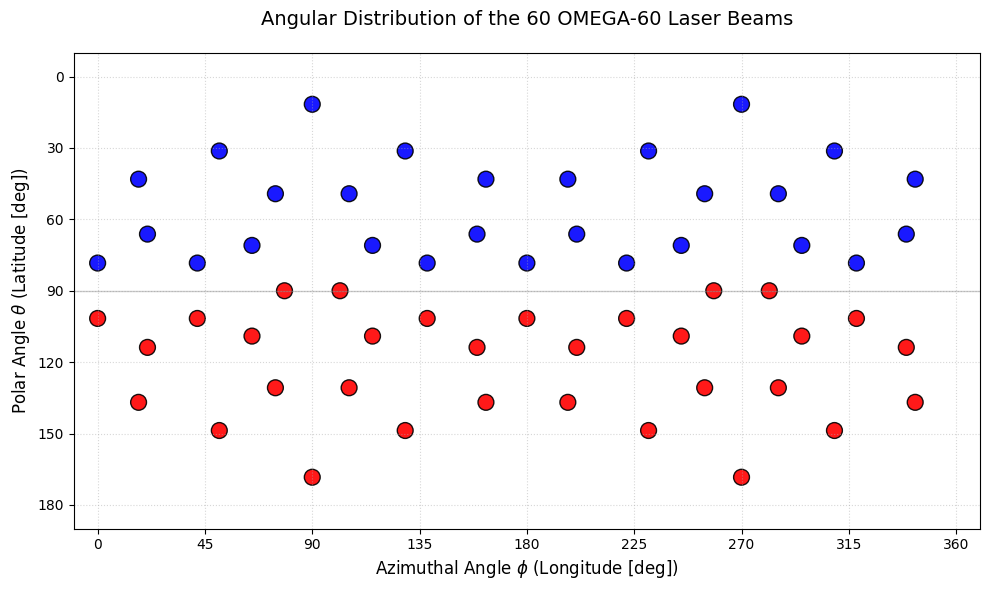

In [5]:
# --- GEOMETRY VISUALIZATION 1: 2D "Flat" Projection (Polar vs. Azimuthal Angles) ---
# This plot mimics a Mercator-like projection to verify the angular distribution.
# Essential for validating the ring offsets and ensuring uniform coverage.

plt.figure(figsize=(10, 6))

# Plotting all beams using the Phi (azimuthal) and Theta (polar) coordinates from 'df_omega'
plt.scatter(df_omega['phi_deg'], df_omega['theta_deg'], 
            c=df_omega['color'], s=130, edgecolors='black', alpha=0.9)

# Plot styling and aesthetics
plt.title('Angular Distribution of the 60 OMEGA-60 Laser Beams', fontsize=14, pad=20)
plt.xlabel('Azimuthal Angle $\phi$ (Longitude [deg])', fontsize=12)
plt.ylabel('Polar Angle $\\theta$ (Latitude [deg])', fontsize=12)

# Set ticks for better readability: every 45° for phi and 30° for theta
plt.xticks(np.arange(0, 361, 45))
plt.yticks(np.arange(0, 181, 30))

plt.xlim(-10, 370)
plt.ylim(190, -10) # Inverting Y-axis to place the North Pole (0°) at the top
plt.grid(True, linestyle=':', alpha=0.5)

# Highlight the equator (90°) for hemispherical separation
plt.axhline(90, color='gray', linestyle='-', linewidth=1, alpha=0.4) 

plt.tight_layout()
plt.show() # Generate the 2D visualization

### top view

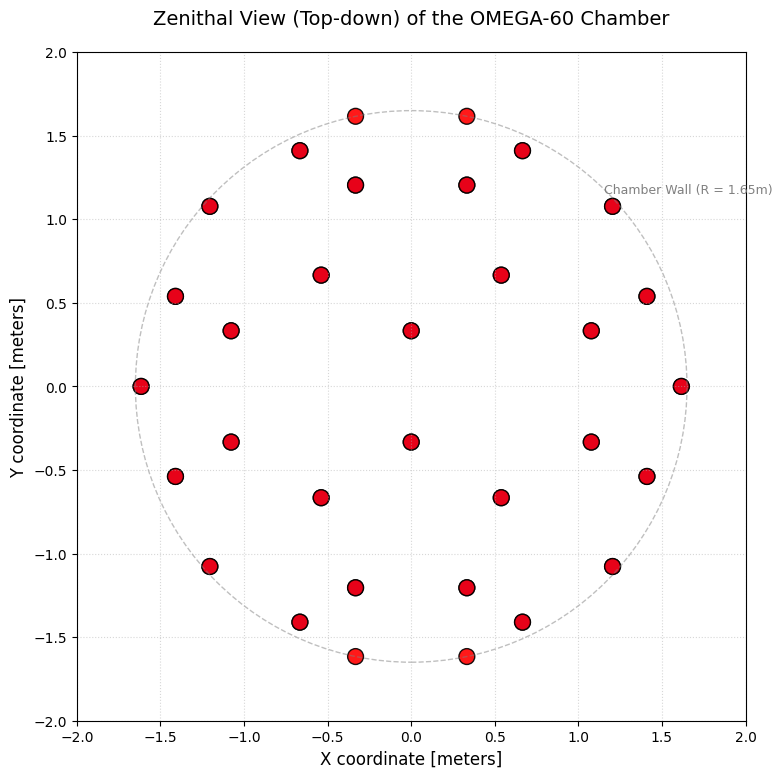

In [6]:
# --- GEOMETRY VISUALIZATION 2: Top-Down View (X vs. Y Projection) ---
# This view provides a zenithal projection to verify the circular symmetry 
# and the azimuthal density of the laser beams within the chamber.


plt.figure(figsize=(8, 8))

# Plotting beam positions using X and Y coordinates from 'df_omega'
plt.scatter(df_omega['X'], df_omega['Y'], 
            c=df_omega['color'], s=130, edgecolors='black', alpha=0.9)

# Representing the target chamber wall (Radius = 1.65m)
chamber_outline = plt.Circle((0, 0), 1.65, color='gray', fill=False, linestyle='--', alpha=0.5)
plt.gca().add_artist(chamber_outline)
plt.text(1.65*0.7, 1.65*0.7, 'Chamber Wall (R = 1.65m)', color='gray', fontsize=9)

# Plot styling and axis configuration
plt.title('Zenithal View (Top-down) of the OMEGA-60 Chamber', fontsize=14, pad=20)
plt.xlabel('X coordinate [meters]', fontsize=12)
plt.ylabel('Y coordinate [meters]', fontsize=12)

# Set axis limits and ensure a 1:1 aspect ratio to avoid geometric distortion
plt.xlim(-2, 2)
plt.ylim(-2, 2)
plt.gca().set_aspect('equal', adjustable='box') 

plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show() # Generate the top-down visualization

### 3D view

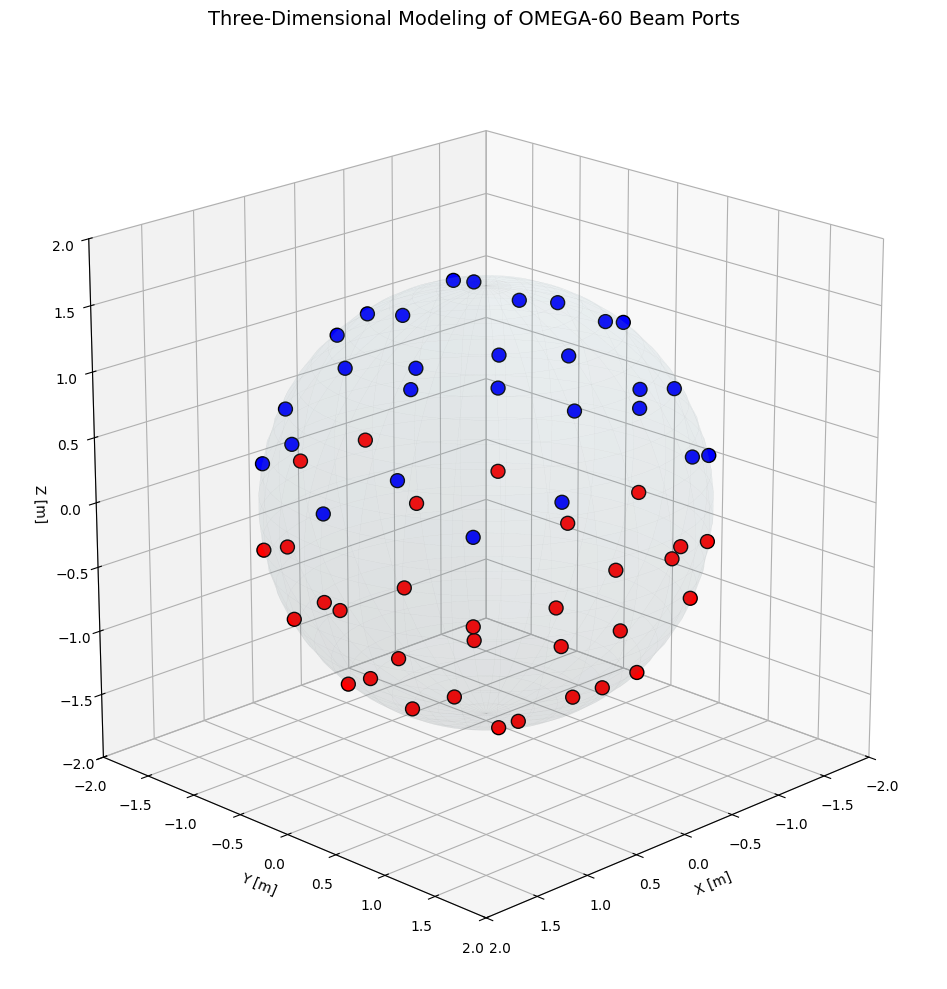

In [7]:
# --- GEOMETRY VISUALIZATION 3: Interactive 3D View (X, Y, Z) ---
# This plot provides a full spatial representation of the OMEGA-60 configuration.
# It is used to validate the overall spherical alignment and global beam distribution.

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

# Plotting beam coordinates (X, Y, Z) from 'df_omega'
# Color mapping: Blue for Northern Hemisphere, Red for Southern Hemisphere
ax.scatter(df_omega['X'], df_omega['Y'], df_omega['Z'], 
           c=df_omega['color'], s=100, edgecolors='black', alpha=1, zorder=10)

# Rendering a transparent wireframe sphere to represent the target chamber
u_sphere = np.linspace(0, 2 * np.pi, 60)
v_sphere = np.linspace(0, np.pi, 30)
x_s = 1.65 * np.outer(np.cos(u_sphere), np.sin(v_sphere))
y_s = 1.65 * np.outer(np.sin(u_sphere), np.sin(v_sphere))
z_s = 1.65 * np.outer(np.ones_like(u_sphere), np.cos(v_sphere))
ax.plot_surface(x_s, y_s, z_s, alpha=0.07, color='lightblue', edgecolor='gray', linewidth=0.1)

# Plot styling and 3D axis configuration
ax.set_title('Three-Dimensional Modeling of OMEGA-60 Beam Ports', fontsize=14, pad=20)
ax.set_xlabel('X [m]')
ax.set_ylabel('Y [m]')
ax.set_zlabel('Z [m]')

# Ensure isotropic scaling (1:1:1) to maintain spherical proportions
ax.set_xlim([-2, 2]); ax.set_ylim([-2, 2]); ax.set_zlim([-2, 2])
ax.set_box_aspect([1, 1, 1]) 

# Set a standard perspective view (Elevation: 20°, Azimuth: 45°)
ax.view_init(elev=20, azim=45) 

plt.tight_layout()
plt.show() # Generate the 3D visualization

## Define and create beams based on Omega 60

In [8]:
df_omega = geometry.get_omega60_dataframe()

df_omega[['fx', 'fy', 'fz']] = df_omega.apply(
    geometry.assign_beam_focus, 
    defocus_value=my_defocus, 
    axis=1
)

# Data verification

# 3. Écriture du fichier Excel
# On l'appelle "master_config" car c'est la référence pour le sampler
rwbeams.write_beams(df_omega, "omega60_master_config.xlsx")

print(f"Fichier config créé avec R={CHAMBER_RADIUS}m et Defocus={my_defocus}mm")

print(f"Final OMEGA-60 table generated with {len(df_omega)} rows.")
df_omega.head(10)
    

# Beams successfully written to omega60_master_config.xlsx
Fichier config créé avec R=1.65m et Defocus=0mm
Final OMEGA-60 table generated with 60 rows.


,id,LAT_rad,LONG_rad,energy,wavelength,l1,l2,xc,yc,zc,...,t1x,t1y,t1z,t2x,t2y,t2z,R,fx,fy,fz
0,OMEGA_J01,0.203169,1.570796,500.0,3.510000e-07,0.28,0.28,2.038592e-17,0.332927,1.616063,...,-1.000000,6.123234e-17,0.0,-5.997292e-17,-0.979432,0.201774,0.14,-6.818032e-20,-0.001113,-0.005405
1,OMEGA_J02,0.203169,4.712389,500.0,3.510000e-07,0.28,0.28,-6.115775e-17,-0.332927,1.616063,...,1.000000,-1.836970e-16,0.0,1.799188e-16,0.979432,0.201774,0.14,2.045410e-19,0.001113,-0.005405
2,OMEGA_J03,0.545768,0.890581,500.0,3.510000e-07,0.28,0.28,5.386876e-01,0.665855,1.410303,...,-0.777438,6.289602e-01,0.0,-5.375904e-01,-0.664498,0.519075,0.14,-1.801631e-03,-0.002227,-0.004717
3,OMEGA_J04,0.545768,2.251011,500.0,3.510000e-07,0.28,0.28,-5.386876e-01,0.665855,1.410303,...,-0.777438,-6.289602e-01,0.0,5.375904e-01,-0.664498,0.519075,0.14,1.801631e-03,-0.002227,-0.004717
4,OMEGA_J05,0.545768,4.032174,500.0,3.510000e-07,0.28,0.28,-5.386876e-01,-0.665855,1.410303,...,0.777438,-6.289602e-01,0.0,5.375904e-01,0.664498,0.519075,0.14,1.801631e-03,0.002227,-0.004717
5,OMEGA_J06,0.545768,5.392604,500.0,3.510000e-07,0.28,0.28,5.386876e-01,-0.665855,1.410303,...,0.777438,6.289602e-01,0.0,-5.375904e-01,0.664498,0.519075,0.14,-1.801631e-03,0.002227,-0.004717
6,OMEGA_J07,0.752437,0.299709,500.0,3.510000e-07,0.28,0.28,1.077375e+00,0.332927,1.204542,...,-0.295242,9.554226e-01,0.0,-6.974829e-01,-0.215534,0.683420,0.14,-3.603262e-03,-0.001113,-0.004029
7,OMEGA_J08,0.752437,2.841884,500.0,3.510000e-07,0.28,0.28,-1.077375e+00,0.332927,1.204542,...,-0.295242,-9.554226e-01,0.0,6.974829e-01,-0.215534,0.683420,0.14,3.603262e-03,-0.001113,-0.004029
8,OMEGA_J09,0.752437,3.441301,500.0,3.510000e-07,0.28,0.28,-1.077375e+00,-0.332927,1.204542,...,0.295242,-9.554226e-01,0.0,6.974829e-01,0.215534,0.683420,0.14,3.603262e-03,0.001113,-0.004029
9,OMEGA_J10,0.752437,5.983477,500.0,3.510000e-07,0.28,0.28,1.077375e+00,-0.332927,1.204542,...,0.295242,9.554226e-01,0.0,-6.974829e-01,0.215534,0.683420,0.14,-3.603262e-03,0.001113,-0.004029


## Create 3D simulation of beams modeling them as if they were a cone, to see focal distance

### 1 window simulation to see focal distance

In [9]:
import pyvista as pv

In [10]:
import pyvista as pv
import numpy as np
import pandas as pd
from pyvista.trame.jupyter import launch_server

# 1. Initialisation du serveur Jupyter
await launch_server().ready

# --- Sélection du PREMIER FAISCEAU ---
# On suppose que df_omega a été généré par geometry.get_omega60_dataframe()
# Il contient déjà xc, yc, zc, fx, fy, fz, t1x, t1y, t1z, t2x, t2y, t2z, R, etc.
row = df_omega.iloc[0]  

# --- Initialiser le Plotter ---
plotter = pv.Plotter()
plotter.set_background("white")

# 1. Dessiner la Cible (Capsule de 1 mm) - Jaune
# TARGET_RADIUS vient de ton module geometry (0.001m)
target = pv.Sphere(radius=geometry.TARGET_RADIUS, center=(0.0, 0.0, 0.0), 
                   theta_resolution=100, phi_resolution=100)
plotter.add_mesh(target, color="yellow", opacity=1.0, label="Cible (1mm)")

# 2. Sphère de la chambre (Transparente pour le contexte)
# CHAMBER_RADIUS vient de geometry (1.65m)
chamber = pv.Sphere(radius=geometry.CHAMBER_RADIUS, theta_resolution=60, phi_resolution=60)
plotter.add_mesh(chamber, color="lightblue", opacity=0.1)

# 3. Reconstruction des vecteurs depuis les colonnes éclatées
# On utilise les noms exacts définis dans ta Master Table
port_center = np.array([row['xc'], row['yc'], row['zc']])
focus_point = np.array([row['fx'], row['fy'], row['fz']])
t1 = np.array([row['t1x'], row['t1y'], row['t1z']])
t2 = np.array([row['t2x'], row['t2y'], row['t2z']])

# Paramètres du faisceau
beam_color = row.get('color', 'blue') # Par défaut bleu si non spécifié
beam_id = row['id']
beam_radius = row['R'] # Correspond à BEAM_RADIUS (0.14m)

# --- Visualisation de la Fenêtre (Window) ---
# Carré de la fenêtre (Wireframe)
side_length = beam_radius * 2
p1 = port_center + beam_radius * t1 + beam_radius * t2
p2 = port_center - beam_radius * t1 + beam_radius * t2
p3 = port_center - beam_radius * t1 - beam_radius * t2
p4 = port_center + beam_radius * t1 - beam_radius * t2

quad = pv.PolyData([p1, p2, p3, p4], [[4, 0, 1, 2, 3]])
plotter.add_mesh(quad, color="black", style="wireframe", line_width=2)

# Cercle inscrit (Base du faisceau)
phi_vals = np.linspace(0, 2*np.pi, 100)
circ_pts = port_center + (beam_radius * np.cos(phi_vals))[:, None] * t1 + \
                         (beam_radius * np.sin(phi_vals))[:, None] * t2
circle = pv.MultipleLines(circ_pts)
plotter.add_mesh(circle, color=beam_color, line_width=4, label=f"Base {beam_id}")

# --- MODÉLISATION DU CÔNE (Faisceau Laser) ---
# Vecteur du centre du port vers le foyer (Focus)
direction_vector = focus_point - port_center
height = np.linalg.norm(direction_vector)
dir_u = direction_vector / height

# Le centre du cône PyVista est le milieu de sa hauteur
cone_center = port_center + (dir_u * (height / 2.0))

cone = pv.Cone(
    center=cone_center,
    direction=dir_u,
    height=height,
    radius=beam_radius, # Rayon à la base
    resolution=100,
    capping=True
)
plotter.add_mesh(cone, color=beam_color, opacity=0.3, label=f"Faisceau {beam_id}")

# --- Ajustements de caméra et axes ---
plotter.add_legend()
plotter.add_axes()

# Focus sur la cible au centre (0,0,0)
plotter.camera.position = (0.1, 0.1, 0.1) # Reculer un peu pour voir le cône arriver
plotter.camera.focal_point = (0, 0, 0)
plotter.show()

Widget(value='<iframe src="http://localhost:64332/index.html?ui=P_0x1ee82c1ce90_0&reconnect=auto" class="pyvis…

### All beams simulation

In [11]:
import pyvista as pv
import numpy as np
import pandas as pd

# --- Initialiser le plotter ---
plotter = pv.Plotter()
plotter.set_background("white")

# 1. Dessiner la Cible au centre (Capsule de 1 mm)
# On utilise la constante TARGET_RADIUS du module geometry
target = pv.Sphere(radius=geometry.TARGET_RADIUS, center=(0.0, 0.0, 0.0), 
                   theta_resolution=100, phi_resolution=100)
plotter.add_mesh(target, color="yellow", opacity=1.0, label="Cible (1mm)")

# 2. Sphère de la chambre (Structure globale)
# On utilise la constante CHAMBER_RADIUS du module geometry
chamber = pv.Sphere(radius=geometry.CHAMBER_RADIUS, theta_resolution=60, phi_resolution=60)
plotter.add_mesh(chamber, color="lightblue", opacity=0.1)

# --- Parcourir le DataFrame OMEGA (60 faisceaux) ---
# On utilise le DataFrame généré par geometry.get_omega60_dataframe()
for idx, row in df_omega.iterrows():
    # Détermination de la couleur (basée sur l'hémisphère si disponible)
    # Note: On peut rajouter la logique de couleur ici si elle n'est pas dans le DF
    beam_color = "blue" if row['LAT_rad'] < np.pi/2 else "red"
    
    # 3. Reconstruction des vecteurs à partir des colonnes éclatées
    port_center = np.array([row['xc'], row['yc'], row['zc']])
    focus_point = np.array([row['fx'], row['fy'], row['fz']])
    t1 = np.array([row['t1x'], row['t1y'], row['t1z']])
    t2 = np.array([row['t2x'], row['t2y'], row['t2z']])
    
    # Rayon du faisceau (R) stocké dans le DataFrame
    beam_r = row['R']
    
    # 4. Dessiner la base CIRCULAIRE sur la paroi de la chambre
    phi_vals = np.linspace(0, 2*np.pi, 50)
    circle_pts = port_center + (beam_r * np.cos(phi_vals))[:, None] * t1 + \
                               (beam_r * np.sin(phi_vals))[:, None] * t2
    circle = pv.MultipleLines(circle_pts)
    plotter.add_mesh(circle, color=beam_color, line_width=2)

    # 5. Modélisation du Faisceau comme un CÔNE
    # Vecteur directionnel du port vers le foyer
    direction_vector = focus_point - port_center
    height = np.linalg.norm(direction_vector)
    dir_u = direction_vector / height
    
    # Le centre du cône PyVista est le milieu du segment port-focus
    cone_center = port_center + (dir_u * (height / 2.0))
    
    # Création du cône représentant le faisceau convergeant
    cone = pv.Cone(
        center=cone_center,
        direction=dir_u,
        height=height,
        radius=beam_r, 
        resolution=30, # Résolution réduite pour fluidifier l'affichage de 60 faisceaux
        capping=True
    )
    
    # Ajout avec transparence pour visualiser la superposition (effet "ballon de foot")
    plotter.add_mesh(cone, color=beam_color, opacity=0.15, show_edges=False)

# --- Configuration finale de la scène ---
plotter.add_legend()
plotter.add_axes()
plotter.view_isometric()

print(f"Rendu en cours : {len(df_omega)} faisceaux OMEGA-60 détectés.")
plotter.show()

Rendu en cours : 60 faisceaux OMEGA-60 détectés.


Widget(value='<iframe src="http://localhost:64332/index.html?ui=P_0x1ee7f343210_1&reconnect=auto" class="pyvis…